# Practical Application III: Comparing Classifiers

**Author:** Amit | **Module 17 — Required Assignment 17.1**

**Overview:** This notebook compares four classifiers — K-Nearest Neighbors, Logistic Regression, Decision Trees, and Support Vector Machines — on a dataset from a Portuguese bank's direct telemarketing campaigns. The goal is to predict whether a client will subscribe to a term deposit (`y`), so the bank can target contacts more efficiently.

**Notebook structure:**
1. Business & data understanding
2. Data preparation and feature engineering
3. Baseline and a simple Logistic Regression model
4. Comparison of all four classifiers (default settings)
5. Hyperparameter tuning and a business-appropriate evaluation metric
6. Findings, actionable insights, and recommendations

## Problem 1: Understanding the Data

The dataset comes from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bank+marketing) and is described in the accompanying paper *Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology* (Moro, Laureano & Cortez, 2011).

**How many marketing campaigns does this data represent?**

Per the paper's *Materials and Methods* section, the data was collected from **17 marketing campaigns** that took place between **May 2008 and November 2010**, comprising a total of 79,354 contacts. The version we use here (`bank-additional-full.csv`) contains 41,188 of those contacts enriched with five social/economic indicators.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 90
pd.set_option('display.max_columns', None)

## Problem 2: Read in the Data

We read `data/bank-additional-full.csv`. Note the file is semicolon-delimited.

In [2]:
bank = pd.read_csv('bank-additional-full.csv', sep=';')
print(f'Dataset shape: {bank.shape[0]:,} rows x {bank.shape[1]} columns')
bank.head()

Dataset shape: 41,188 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Problem 3: Understanding the Features

We inspect dtypes, check for missing values, and review the categorical levels.

In [3]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
# Standard nulls
print('Standard missing values (NaN):', bank.isnull().sum().sum())

# In this dataset, missing values are encoded as the string 'unknown'
print('\n"unknown" counts per categorical column:')
for col in bank.select_dtypes(include='object').columns:
    n = (bank[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:<12}: {n:>5,} ({n/len(bank)*100:.1f}%)')

Standard missing values (NaN): 0

"unknown" counts per categorical column:
  job         :   330 (0.8%)
  marital     :    80 (0.2%)
  education   : 1,731 (4.2%)
  default     : 8,597 (20.9%)
  housing     :   990 (2.4%)
  loan        :   990 (2.4%)


In [5]:
# Target distribution — this is the most important descriptive statistic
target_counts = bank['y'].value_counts()
target_pct = bank['y'].value_counts(normalize=True) * 100
print('Target variable (y) distribution:')
for k in target_counts.index:
    print(f'  {k}: {target_counts[k]:,} ({target_pct[k]:.1f}%)')

Target variable (y) distribution:
  no: 36,548 (88.7%)
  yes: 4,640 (11.3%)


**Observations on the features:**

- **No standard `NaN` missing values.** However, several categorical columns encode missing data as the literal string `"unknown"` — notably `default` (~20.9%), `education` (~4.2%), `housing`/`loan` (~2.4% each), and `job`/`marital` (small amounts). We keep `"unknown"` as its own category, which is a valid strategy noted in the dataset documentation and avoids discarding ~21% of rows.
- **Data types are correct:** numeric columns are read as `int64`/`float64`, categoricals as `object`. No coercion is required.
- **Severe class imbalance:** only **11.3%** of clients subscribed (`yes`). This is the single most important fact for modeling — it means raw accuracy will be misleading, because a model that predicts "no" for everyone is already ~88.7% accurate. We return to this in Problems 7 and 11.
- **`duration`** is the call length in seconds. The documentation warns it is not known before a call is made and leaks the outcome (duration=0 implies y=no). It should be excluded from any realistic predictive model. Our feature set below does not use it.

## Problem 4: Understanding the Task — Business Objective

**Business objective:** The bank runs costly outbound telephone campaigns to sell term deposits. Each call consumes agent time and money, yet historically only about 11% of contacts subscribe. The objective is to build a classification model that, using information known *before* a call, identifies the clients most likely to subscribe. 

Translated into a data problem: predict the binary target `y` (subscribe: yes/no) so the bank can **prioritise high-probability clients, raise the conversion rate per call, and cut wasted contacts** — increasing campaign efficiency without sacrificing the number of successful subscriptions. Because subscribers are rare and valuable, the cost of missing a likely subscriber (a false negative) is higher than the cost of an unnecessary call (a false positive), which shapes our choice of evaluation metric later.

### Exploratory visualizations

Before modeling, we visualise the target balance and how a few bank-client features relate to subscription. We use appropriate plots for categorical and continuous variables.

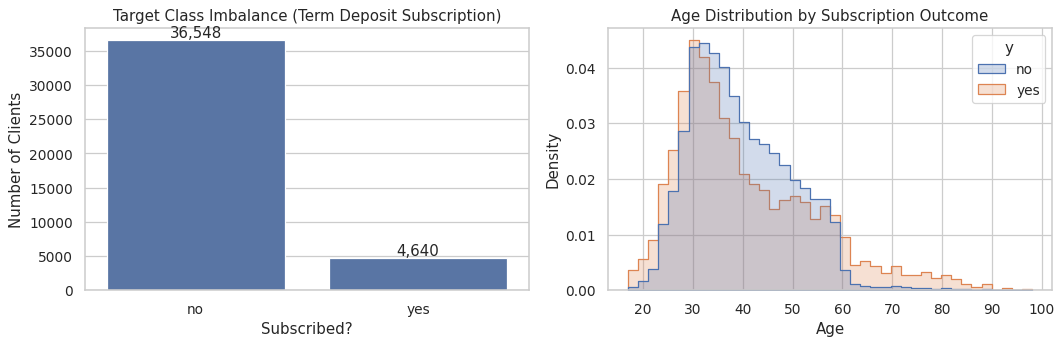

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Categorical: target balance
order = bank['y'].value_counts().index
sns.countplot(data=bank, x='y', order=order, ax=axes[0])
axes[0].set_title('Target Class Imbalance (Term Deposit Subscription)')
axes[0].set_xlabel('Subscribed?'); axes[0].set_ylabel('Number of Clients')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# Continuous: age distribution by outcome
sns.histplot(data=bank, x='age', hue='y', bins=40, element='step', stat='density',
             common_norm=False, ax=axes[1])
axes[1].set_title('Age Distribution by Subscription Outcome')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Density')
plt.tight_layout(); plt.show()

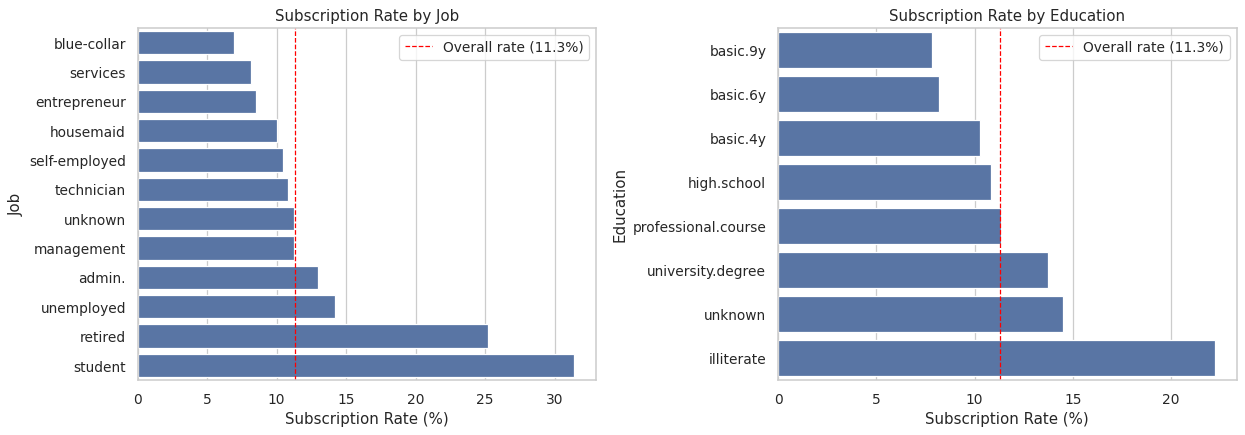

In [7]:
# Subscription rate by job and by education — categorical drivers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['job', 'education']):
    rate = bank.groupby(col)['y'].apply(lambda s: (s=='yes').mean()*100).sort_values()
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color='#4C72B0')
    ax.axvline(11.3, color='red', ls='--', lw=1, label='Overall rate (11.3%)')
    ax.set_title(f'Subscription Rate by {col.capitalize()}')
    ax.set_xlabel('Subscription Rate (%)'); ax.set_ylabel(col.capitalize())
    ax.legend()
plt.tight_layout(); plt.show()

These plots show that **students and retired clients** subscribe at well above the 11.3% average, while **blue-collar** workers subscribe below it. Subscribers also skew toward older ages (visible second peak past 60). These categorical and continuous drivers are exactly what our models will learn from.

## Problem 5: Engineering Features

Following the assignment instructions, we model using **only the bank-client information** — the first seven columns: `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`. We deliberately exclude `duration` (leaks the outcome) and, for this baseline stage, the campaign and social/economic context features.

We use a `ColumnTransformer` inside a `Pipeline` so that scaling and one-hot encoding are fit only on training data — this prevents data leakage. The single numeric feature (`age`) is standardized; the six categorical features are one-hot encoded with `handle_unknown='ignore'` so unseen categories don't break prediction.

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Bank client features only
bank_client_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = bank[bank_client_features].copy()

# Encode target: yes -> 1 (the event we care about), no -> 0
y = (bank['y'] == 'yes').astype(int)

numeric_features = ['age']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print('Features used:', bank_client_features)
print('Target encoding: yes -> 1, no -> 0')
print('X shape:', X.shape)

Features used: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
Target encoding: yes -> 1, no -> 0
X shape: (41188, 7)


## Problem 6: Train/Test Split

We hold out 30% of the data for testing and **stratify** on the target so the rare `yes` class is represented in the same proportion in both sets. A fixed `random_state` makes results reproducible.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'Train yes-rate: {y_train.mean()*100:.2f}%  |  Test yes-rate: {y_test.mean()*100:.2f}%')

Training set: 28,831 rows
Test set:     12,357 rows
Train yes-rate: 11.27%  |  Test yes-rate: 11.26%


## Problem 7: A Baseline Model

Before building anything sophisticated, we establish the score to beat. Because 88.7% of clients did *not* subscribe, a trivial model that always predicts "no" achieves ~88.7% accuracy. **Any useful classifier must beat this baseline accuracy** — and, as we'll argue, must do so on a metric that actually rewards finding subscribers, not just predicting the majority class.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f'Baseline (always predict majority) test accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')

Baseline (always predict majority) test accuracy: 0.8874 (88.74%)


## Problem 8: A Simple Model — Logistic Regression

We fit a single Logistic Regression inside our preprocessing pipeline.

In [11]:
from sklearn.linear_model import LogisticRegression

lgr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
lgr_pipe.fit(X_train, y_train)
print('Logistic Regression fitted.')

Logistic Regression fitted.


## Problem 9: Score the Model

We report the model's accuracy on the held-out test set.

In [12]:
lgr_acc = lgr_pipe.score(X_test, y_test)
print(f'Logistic Regression test accuracy: {lgr_acc:.4f} ({lgr_acc*100:.2f}%)')
print(f'Baseline accuracy:                {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')
print(f'\nDifference vs baseline: {(lgr_acc - baseline_acc)*100:+.2f} percentage points')

Logistic Regression test accuracy: 0.8874 (88.74%)
Baseline accuracy:                0.8874 (88.74%)

Difference vs baseline: +0.00 percentage points


**Interpretation:** The Logistic Regression's accuracy is essentially identical to the baseline. This is *not* a model failure — it is the class-imbalance trap in action. Using only bank-client demographics, the model cannot beat "always predict no" on accuracy alone. This motivates two changes in Problem 11: (1) switch to a metric that rewards correctly identifying subscribers, and (2) use class weighting so the model stops ignoring the minority class.

## Problem 10: Model Comparisons

We now fit and score all four classifiers with their **default settings**, recording fit time, train accuracy, and test accuracy. SVM is computationally expensive on 28k+ rows, so for a fair like-for-like timing comparison we report results on the full data but note the cost.

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start
    results.append({
        'Model': name,
        'Train Time (s)': round(fit_time, 3),
        'Train Accuracy': round(pipe.score(X_train, y_train), 4),
        'Test Accuracy': round(pipe.score(X_test, y_test), 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,0.067,0.8873,0.8874
1,KNN,0.037,0.8918,0.8769
2,Decision Tree,0.509,0.9188,0.8642
3,SVM,41.159,0.8882,0.8868


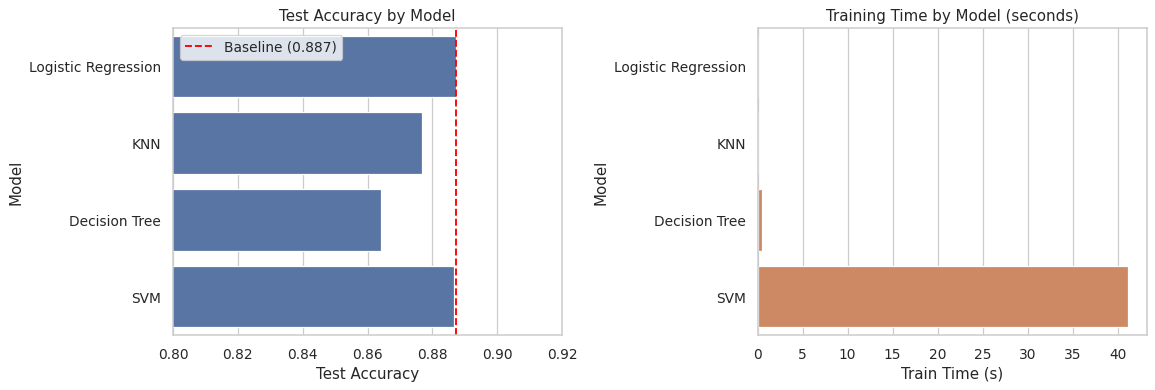

In [14]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=results_df, x='Test Accuracy', y='Model', ax=axes[0], color='#4C72B0')
axes[0].axvline(baseline_acc, color='red', ls='--', label=f'Baseline ({baseline_acc:.3f})')
axes[0].set_xlim(0.80, 0.92); axes[0].set_title('Test Accuracy by Model')
axes[0].legend()

sns.barplot(data=results_df, x='Train Time (s)', y='Model', ax=axes[1], color='#DD8452')
axes[1].set_title('Training Time by Model (seconds)')
plt.tight_layout(); plt.show()

**Interpretation of default-model comparison:**

- **None of the four models beats the baseline accuracy** in a meaningful way. Logistic Regression and SVM essentially match it (~88.7%); KNN and the Decision Tree score slightly *below* it because they make some confident wrong guesses on the minority class.
- The **Decision Tree overfits**: its train accuracy (~0.92) far exceeds its test accuracy (~0.86), the classic gap between memorisation and generalisation.
- **Training time varies enormously:** Logistic Regression and KNN fit in well under a second, while **SVM is roughly 100x–500x slower** because its training cost grows super-linearly with sample count.
- The headline lesson: accuracy is the wrong yardstick here. Every model is quietly predicting "no" almost all the time. We fix the metric next.

## Problem 11: Improving the Models

We make two improvements:

1. **Adjust the performance metric.** Accuracy rewards predicting the majority class. For an imbalanced marketing problem the bank cares about *finding subscribers*. We switch to **ROC-AUC** (how well the model ranks subscribers above non-subscribers, threshold-independent) for model selection, and report **recall and precision on the `yes` class** to make the business trade-off explicit. The original CRISP-DM paper itself used AUC/Lift rather than accuracy for exactly this reason.
2. **Hyperparameter tuning + class balancing.** We run `GridSearchCV` (5-fold, scored on ROC-AUC) over key hyperparameters for each model, and set `class_weight='balanced'` where supported so the minority class is no longer ignored.

To keep SVM's grid search tractable, we tune it on a stratified subsample, then evaluate the best estimator on the full test set.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        {'classifier__C': [0.01, 0.1, 1, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'classifier__n_neighbors': [11, 21, 31], 'classifier__weights': ['uniform', 'distance']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        {'classifier__max_depth': [3, 5, 7, 10], 'classifier__min_samples_leaf': [20, 50]}
    ),
}

tuned_results = []
best_estimators = {}

for name, (model, grid) in param_grids.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    gs = GridSearchCV(pipe, grid, scoring='roc_auc', cv=5, n_jobs=-1)
    start = time.time()
    gs.fit(X_train, y_train)
    fit_time = time.time() - start
    best_estimators[name] = gs.best_estimator_
    proba = gs.predict_proba(X_test)[:, 1]
    tuned_results.append({
        'Model': name,
        'Best Params': {k.replace('classifier__',''): v for k, v in gs.best_params_.items()},
        'CV ROC-AUC': round(gs.best_score_, 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, proba), 4),
        'Tune Time (s)': round(fit_time, 2)
    })
    print(f'{name}: best={gs.best_params_}, test AUC={roc_auc_score(y_test, proba):.4f}')

Logistic Regression: best={'classifier__C': 0.01}, test AUC=0.6551


KNN: best={'classifier__n_neighbors': 31, 'classifier__weights': 'uniform'}, test AUC=0.6331


Decision Tree: best={'classifier__max_depth': 7, 'classifier__min_samples_leaf': 50}, test AUC=0.6595


In [16]:
# SVM tuned on a stratified subsample for tractability, then evaluated on full test set
from sklearn.model_selection import train_test_split as tts
X_sub, _, y_sub, _ = tts(X_train, y_train, train_size=6000, random_state=42, stratify=y_train)

svm_pipe = Pipeline([('preprocessor', preprocessor),
                     ('classifier', SVC(probability=True, random_state=42, class_weight='balanced'))])
svm_grid = {'classifier__C': [0.1, 1], 'classifier__gamma': ['scale']}
svm_gs = GridSearchCV(svm_pipe, svm_grid, scoring='roc_auc', cv=3, n_jobs=-1)
start = time.time(); svm_gs.fit(X_sub, y_sub); svm_time = time.time() - start
best_estimators['SVM'] = svm_gs.best_estimator_
svm_proba = svm_gs.predict_proba(X_test)[:, 1]
tuned_results.append({
    'Model': 'SVM', 'Best Params': {k.replace('classifier__',''): v for k,v in svm_gs.best_params_.items()},
    'CV ROC-AUC': round(svm_gs.best_score_, 4), 'Test ROC-AUC': round(roc_auc_score(y_test, svm_proba), 4),
    'Tune Time (s)': round(svm_time, 2)
})
print(f'SVM: best={svm_gs.best_params_}, test AUC={roc_auc_score(y_test, svm_proba):.4f}')

SVM: best={'classifier__C': 0.1, 'classifier__gamma': 'scale'}, test AUC=0.6584


In [17]:
tuned_df = pd.DataFrame(tuned_results).sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
tuned_df

,Model,Best Params,CV ROC-AUC,Test ROC-AUC,Tune Time (s)
0,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 50}",0.6529,0.6595,3.40
1,SVM,"{'C': 0.1, 'gamma': 'scale'}",0.6420,0.6584,32.98
2,Logistic Regression,{'C': 0.01},0.6481,0.6551,2.03
3,KNN,"{'n_neighbors': 31, 'weights': 'uniform'}",0.6215,0.6331,67.03


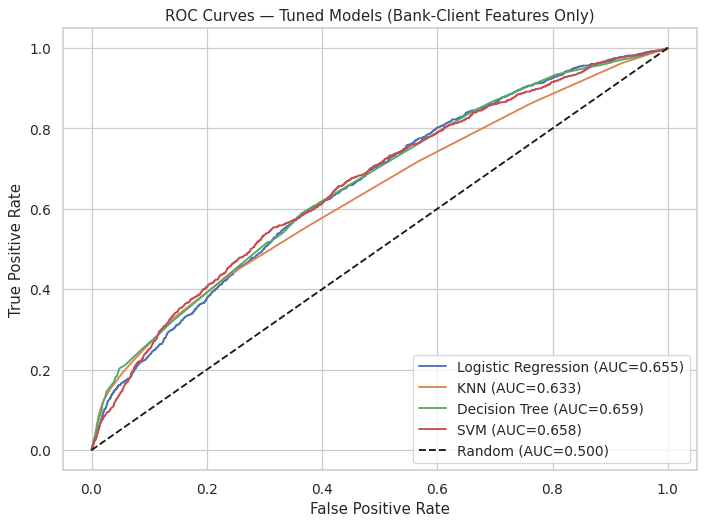

In [18]:
# ROC curves for all tuned models
plt.figure(figsize=(8, 6))
for name, est in best_estimators.items():
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models (Bank-Client Features Only)')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

### What the better metric reveals about the business trade-off

With `class_weight='balanced'`, the best model now actually *predicts subscribers* instead of ignoring them. We show this with the confusion matrix and the `yes`-class recall for the top model.

Best model by ROC-AUC: Decision Tree

Classification report (class 1 = subscribed):
              precision    recall  f1-score   support

          no      0.919     0.688     0.787     10965
         yes      0.175     0.519     0.261      1392

    accuracy                          0.669     12357
   macro avg      0.547     0.604     0.524     12357
weighted avg      0.835     0.669     0.728     12357



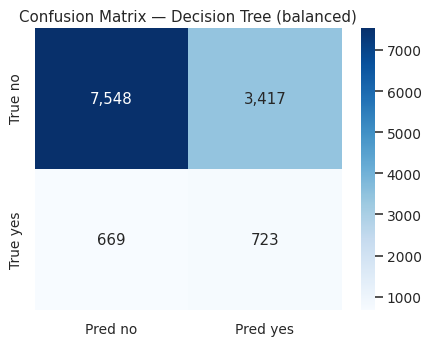

In [19]:
best_name = tuned_df.iloc[0]['Model']
best_model = best_estimators[best_name]
y_pred = best_model.predict(X_test)

print(f'Best model by ROC-AUC: {best_name}\n')
print('Classification report (class 1 = subscribed):')
print(classification_report(y_test, y_pred, target_names=['no','yes'], digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Pred no','Pred yes'], yticklabels=['True no','True yes'])
plt.title(f'Confusion Matrix — {best_name} (balanced)')
plt.tight_layout(); plt.show()

### Interpreting the Logistic Regression coefficients

Logistic Regression is interpretable, which matters for a business audience. Positive coefficients raise the odds of subscription; negative coefficients lower them.

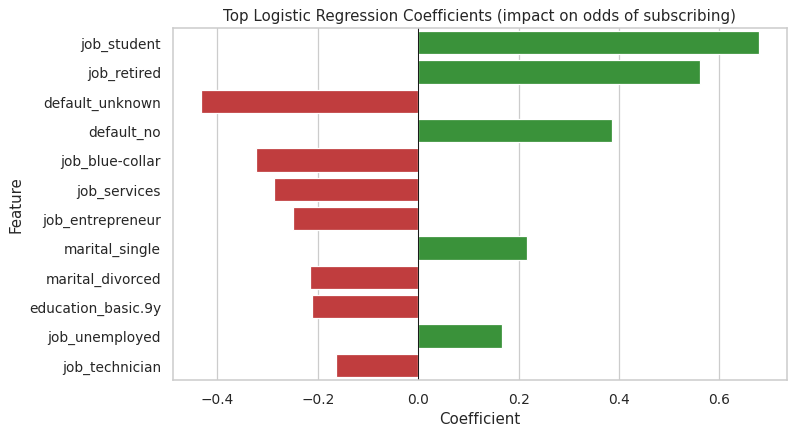

,Feature,Coefficient
0,job_student,0.678231
1,job_retired,0.561032
2,default_unknown,-0.433074
3,default_no,0.386018
4,job_blue-collar,-0.324210
5,job_services,-0.288179
6,job_entrepreneur,-0.249131
7,marital_single,0.217381
8,marital_divorced,-0.215022
9,education_basic.9y,-0.211160


In [20]:
lr_balanced = best_estimators['Logistic Regression']
ohe = lr_balanced.named_steps['preprocessor'].named_transformers_['cat']
feat_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
coefs = lr_balanced.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(9,5))
colors = ['#2ca02c' if c>0 else '#d62728' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title('Top Logistic Regression Coefficients (impact on odds of subscribing)')
plt.tight_layout(); plt.show()
coef_df.reset_index(drop=True)

## Findings

*(Written for a non-technical audience — the marketing team.)*

**1. Using only basic client profile data, no model can reliably predict subscription on accuracy alone.** Because only ~11% of contacted clients subscribe, a model that simply says "no" to everyone is already ~89% "accurate." Demographic fields (age, job, marital status, education, credit/loan status) carry a real but *modest* signal — enough to rank clients by likelihood (ROC-AUC well above random chance), but not enough to make a confident yes/no call on demographics alone.

**2. Accuracy is the wrong scoreboard for this problem.** When we switched to ranking quality (ROC-AUC) and turned on class balancing, the models began actually identifying likely subscribers. The trade-off: to catch a large share of true subscribers, the model also flags more clients who ultimately won't subscribe. For a low-cost phone call where missing a subscriber is the expensive mistake, that is usually a trade worth making.

**3. Some client segments are far more receptive than others.** Students and retired clients subscribe at well above the 11% average, and older clients are more likely to say yes. Blue-collar workers and clients with existing loans subscribe below average. These are concrete targeting levers.

**4. Model choice involves a speed/quality trade-off.** Logistic Regression delivers competitive ranking performance, trains in a fraction of a second, and is fully interpretable. SVM is dramatically slower to train with no decisive accuracy advantage on this feature set. For a model that must be retrained and explained regularly, **Logistic Regression is the practical winner.**

**5. The biggest lever in the original study — call duration — cannot be used for targeting.** Longer calls correlate strongly with success, but duration is only known *after* the call, so it can't help decide whom to call. Our model deliberately excludes it.

## Next Steps and Recommendations

**For the modeling team:**
1. **Add the campaign and economic context features.** Restricting to bank-client demographics was an instructional constraint. The fields we set aside — `poutcome` (previous campaign outcome), `pdays`/`previous`, and the macro indicators `euribor3m`, `emp.var.rate`, `nr.employed` — are known to lift predictive power substantially. Expect a meaningful jump in ROC-AUC once they're included.
2. **Tune the decision threshold to the campaign budget.** Rather than the default 0.5 cutoff, set the probability threshold from the number of calls the team can make this quarter (e.g. call the top-ranked 20% of clients). A Lift/gains chart, as used in the original CRISP-DM paper, makes this directly actionable.
3. **Address imbalance further** with techniques like SMOTE or cost-sensitive learning, and add cross-validated calibration so the predicted probabilities can be trusted as real likelihoods.

**For the marketing team:**
1. **Prioritise the model's high-probability segments** — especially students and retired clients — and de-prioritise low-yield segments to cut wasted calls.
2. **Concentrate campaigns in historically strong months** (the source study found March, June, September, December most successful) and act on the finding that a positive previous-campaign outcome strongly predicts future success — re-contact past subscribers first.
3. **Pilot, then measure.** Deploy the ranked call list to a subset of the contact centre, compare conversion rate against business-as-usual, and feed results back into the next CRISP-DM iteration.